# 分支并发
> 在实际的智能体系统中，流程往往不是简单的线性执行，而是会根据不同的情况和条件，出现分支、并行、循环等复杂的控制流。

* 在最简单的 LangGraph 流程中，我们使用普通边将节点串联起来，形成一条线性的执行路径。但线性流程有其局限性：
    * 无法处理条件判断：线性流程无法根据状态或外部条件，动态地选择不同的执行路径
    * 无法实现并行执行：线性流程只能串行地执行节点，无法同时执行多个独立的任务
    * 效率较低：对于一些可以并行处理的任务，线性流程的串行执行方式会浪费计算资源



## 1. 并行分支-扇入与扇出
》看图就明白

In [1]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# 定义状态，使用 operator.add Reducer 处理并行分支的状态更新
class ParallelState(TypedDict):
    aggregate: Annotated[list, operator.add]

def node_a(state: ParallelState):
    print(f'Adding "A" to {state["aggregate"]}')
    return {"aggregate": ["A"]}

def node_b(state: ParallelState):
    print(f'Adding "B" to {state["aggregate"]}')
    return {"aggregate": ["B"]}

def node_c(state: ParallelState):
    print(f'Adding "C" to {state["aggregate"]}')
    return {"aggregate": ["C"]}

def node_d(state: ParallelState):
    print(f'Adding "D" to {state["aggregate"]}')
    return {"aggregate": ["D"]}

# 构建并行分支图
builder = StateGraph(ParallelState)

# 添加节点
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)

# 添加边：实现扇出和扇入
builder.add_edge(START, "node_a")  # 从 START 到 node_a
builder.add_edge("node_a", "node_b")  # node_a 扇出到 node_b
builder.add_edge("node_a", "node_c")  # node_a 扇出到 node_c (实现扇出)
builder.add_edge("node_b", "node_d")  # node_b 扇入到 node_d
builder.add_edge("node_c", "node_d")  # node_c 扇入到 node_d (实现扇入)
builder.add_edge("node_d", END)  # node_d 到 END

# 编译图
parallel_graph = builder.compile()

print("并行分支图构建完成")
print("流程: START -> node_a -> (node_b, node_c 并行) -> node_d -> END")

# 执行并行分支流程
print("\n执行并行分支流程:")
result = parallel_graph.invoke({"aggregate": []})
print(f"\n最终结果: {result}")

并行分支图构建完成
流程: START -> node_a -> (node_b, node_c 并行) -> node_d -> END

执行并行分支流程:
Adding "A" to []
Adding "B" to ['A']
Adding "C" to ['A']
Adding "D" to ['A', 'B', 'C']

最终结果: {'aggregate': ['A', 'B', 'C', 'D']}


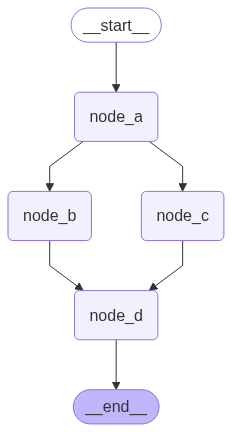

In [2]:
from IPython.display import Image, display

try:
    display(Image(parallel_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

## 递归限制与并行分支
用于限制 LangGraph 图执行过程中的最大 Superstep 迭代次数
防止图无限循环执行

In [3]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.errors import GraphRecursionError  # 导入 GraphRecursionError

class State(TypedDict):
    # operator.add 是状态归约器，确保状态键 aggregate 为 append-only 列表
    aggregate: Annotated[list, operator.add]

def node_a(state):
    print("🔄 执行节点 A")
    return {"aggregate": ["I'm A"]}

def node_b(state):
    print("🔄 执行节点 B")
    return {"aggregate": ["I'm B"]}

def node_c(state):
    print("🔄 执行节点 C")
    return {"aggregate": ["I'm C"]}

def node_d(state):
    print("🔄 执行节点 D")
    return {"aggregate": ["I'm D"]}

# 构建图
print("🏗️ 构建并行分支图...")
builder = StateGraph(State)
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)
builder.add_node("d", node_d)

# 添加边 - 创建并行分支结构
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")  # 从 a 扇出到 b 和 c
builder.add_edge("b", "d")
builder.add_edge("c", "d")  # b 和 c 扇入到 d
builder.add_edge("d", END)

graph = builder.compile()
print("✅ 图构建完成！")

print("\n=== 递归限制和并行分支流程的限制 ===\n")

# 测试 1: 正常执行（在递归限制内）
print("📊 测试 1: 正常执行 (recursion_limit=10)")
try:
    result = graph.invoke({"aggregate": []}, {"recursion_limit": 10})
    print(f"✅ 执行成功，最终结果: {result}")
except Exception as e:
    print(f"❌ 执行失败: {e}")

print("\n" + "="*60)

# 测试 2: 设置较低的递归限制来触发 GraphRecursionError
print("📊 测试 2: 递归限制过低 (recursion_limit=3)")
try:
    # 设置 recursion_limit=3，少于完整流程所需的 Superstep 数量
    result = graph.invoke({"aggregate": []}, {"recursion_limit": 3})
    print(f"✅ 执行成功，结果: {result}")
except GraphRecursionError as e:
    print(f"⚠️ 捕获 GraphRecursionError 异常: {e}")
    print("📝 说明: 递归限制过低，无法完成完整的并行分支流程")

🏗️ 构建并行分支图...
✅ 图构建完成！

=== 递归限制和并行分支流程的限制 ===

📊 测试 1: 正常执行 (recursion_limit=10)
🔄 执行节点 A
🔄 执行节点 B
🔄 执行节点 C
🔄 执行节点 D
✅ 执行成功，最终结果: {'aggregate': ["I'm A", "I'm B", "I'm C", "I'm D"]}

📊 测试 2: 递归限制过低 (recursion_limit=3)
🔄 执行节点 A
🔄 执行节点 B
🔄 执行节点 C
🔄 执行节点 D
⚠️ 捕获 GraphRecursionError 异常: Recursion limit of 3 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT
📝 说明: 递归限制过低，无法完成完整的并行分支流程


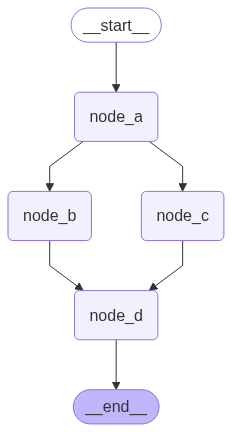

In [4]:
from IPython.display import Image, display

try:
    display(Image(parallel_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass